# 02 — Predictive Modeling Pipeline (Titanic)
### Zepto Analytics Pipeline — Module 2, Part B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                              mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## Load the shared, already-cleaned-once dataset

In [2]:
df = pd.read_csv("titanic.csv")
print("Loaded shape:", df.shape)
df.head()


Loaded shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Task 6 — Feature selection and stratified train/test split


In [3]:
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target_col = 'survived'

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Class balance:\n", y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Class balance:
 survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Train shape: (712, 7)  Test shape: (179, 7)
Train class balance:
 survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Test class balance:
 survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## Task 7 — Leakage-safe preprocessing (`ColumnTransformer` + `Pipeline`)

In [4]:
numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_cols = ['sex', 'embarked']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),
    ]), categorical_cols),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Task 8 — Train three classifiers (Logistic Regression, Decision Tree, Random Forest)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


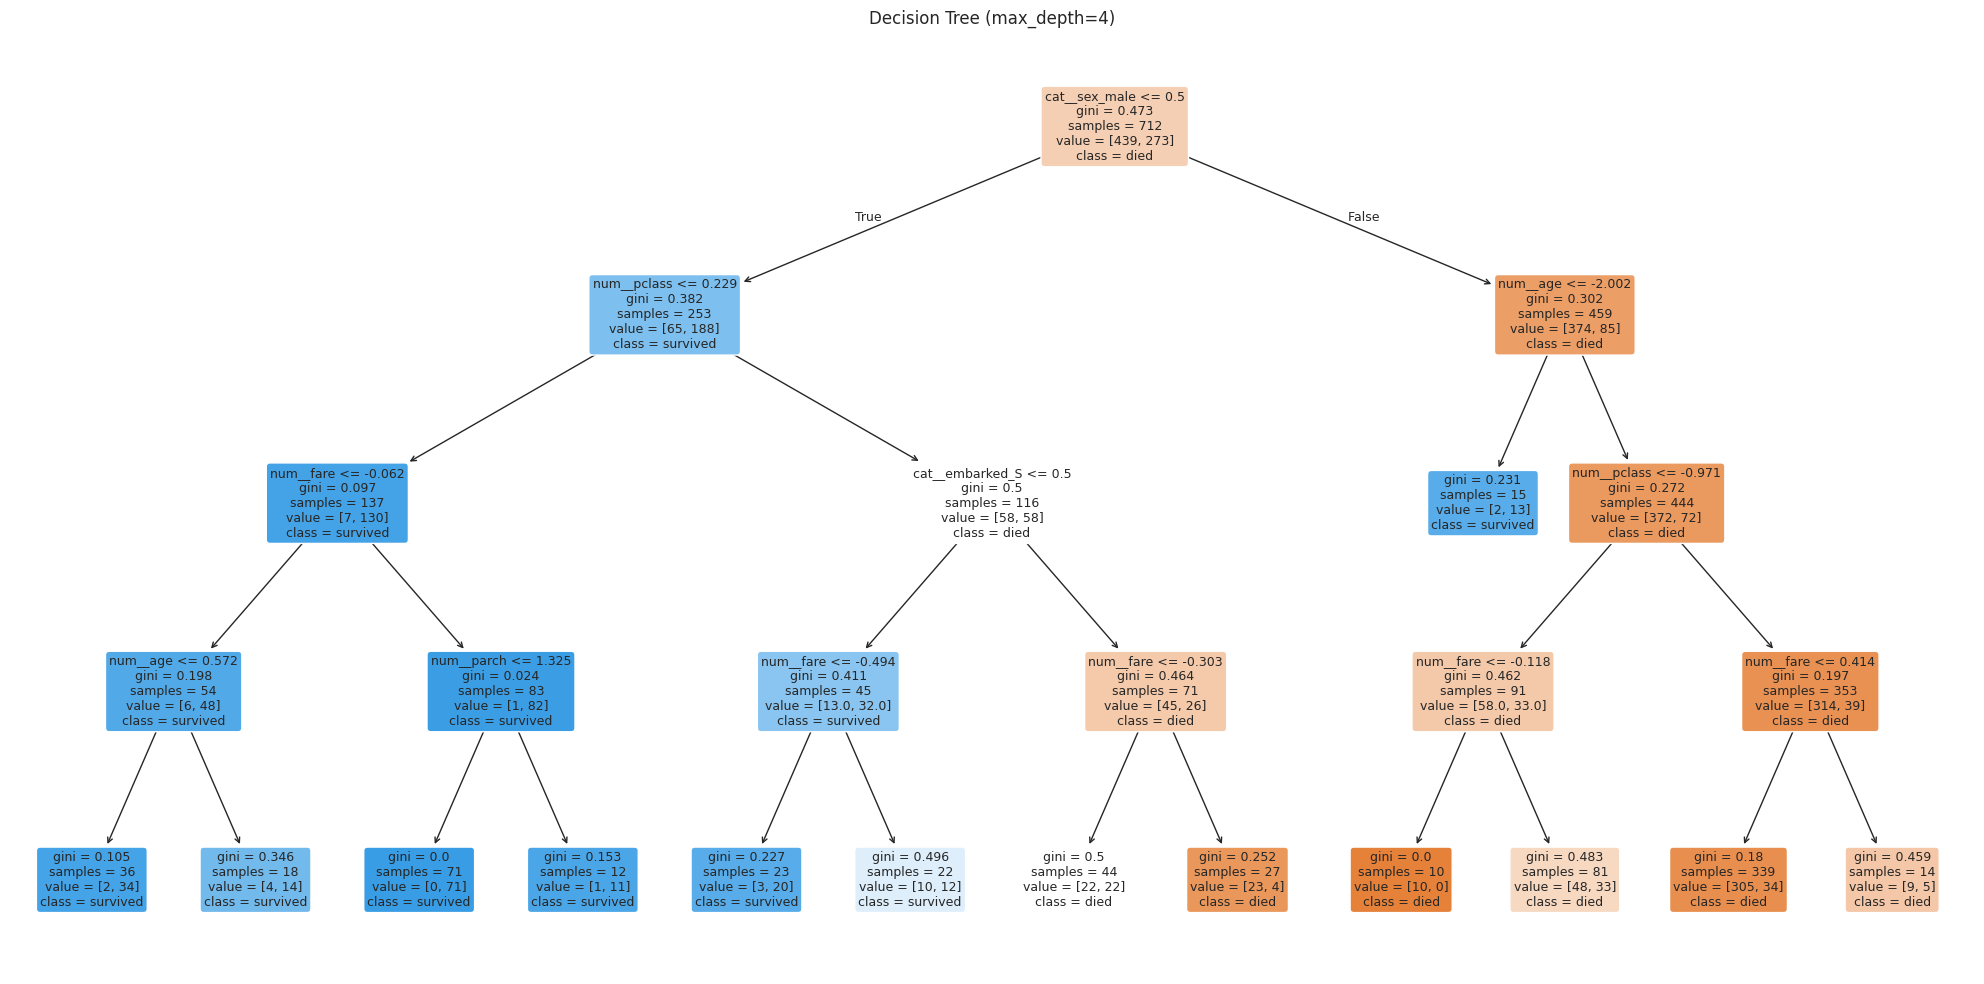

In [ ]:
# Decision tree visualization with labeled feature/class names
dt_pipe = fitted_pipelines['Decision Tree']
feature_names_out = dt_pipe.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(dt_pipe.named_steps['clf'], feature_names=feature_names_out,
          class_names=['died', 'survived'], filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.savefig('charts/08_decision_tree.png', dpi=150)
plt.show()


## Task 9 — Evaluate all three models

Confusion matrix, accuracy, precision, recall, F1, and ROC/AUC for each model, then a single
side-by-side comparison table.


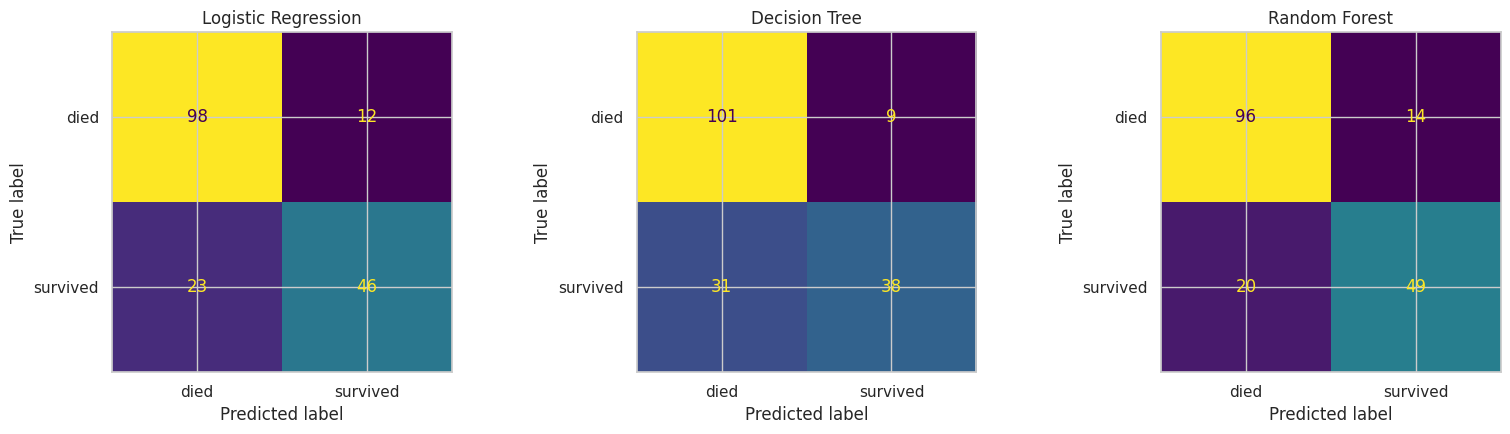

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8435
Decision Tree,0.7765,0.8085,0.5507,0.6552,0.8144
Random Forest,0.8101,0.7778,0.7101,0.7424,0.8310


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
eval_rows = []

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    eval_rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                       'Recall': rec, 'F1': f1, 'AUC': auc})

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['died', 'survived']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('charts/09_confusion_matrices.png', dpi=150)
plt.show()

classifier_comparison = pd.DataFrame(eval_rows).set_index('Model').round(4)
classifier_comparison


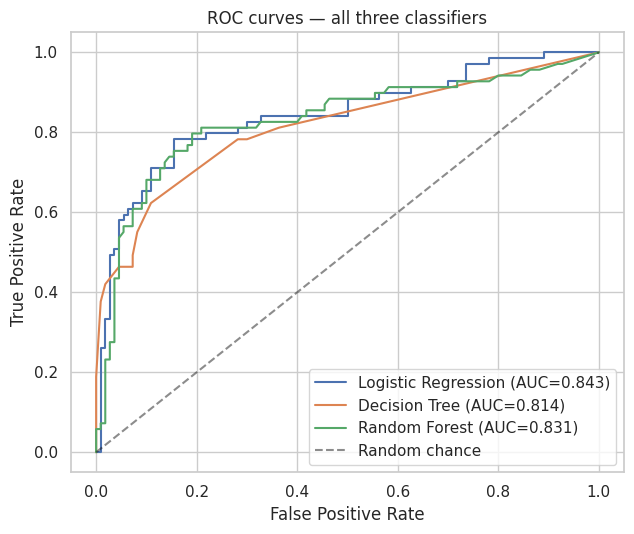

In [8]:
plt.figure(figsize=(6.5, 5.5))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — all three classifiers')
plt.legend()
plt.tight_layout()
plt.savefig('charts/10_roc_curves.png', dpi=150)
plt.show()


## Task 10 — Imbalance-handling comparison (baseline vs `class_weight='balanced'` vs SMOTE)

In [9]:
imbalance_results = []

# (a) Baseline - no handling
baseline_pipe = Pipeline([('preprocessor', preprocessor),
                           ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])
baseline_pipe.fit(X_train, y_train)
pred_a = baseline_pipe.predict(X_test)
imbalance_results.append({'Strategy': 'Baseline (no handling)',
                           'Precision': precision_score(y_test, pred_a),
                           'Recall': recall_score(y_test, pred_a),
                           'F1': f1_score(y_test, pred_a)})

# (b) class_weight='balanced'
balanced_pipe = Pipeline([('preprocessor', preprocessor),
                           ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                           random_state=RANDOM_STATE))])
balanced_pipe.fit(X_train, y_train)
pred_b = balanced_pipe.predict(X_test)
imbalance_results.append({'Strategy': "class_weight='balanced'",
                           'Precision': precision_score(y_test, pred_b),
                           'Recall': recall_score(y_test, pred_b),
                           'F1': f1_score(y_test, pred_b)})

# (c) SMOTE - applied to the training fold only, inside the pipeline
smote_pipe = ImbPipeline([('preprocessor', preprocessor),
                           ('smote', SMOTE(random_state=RANDOM_STATE)),
                           ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])
smote_pipe.fit(X_train, y_train)
pred_c = smote_pipe.predict(X_test)
imbalance_results.append({'Strategy': 'SMOTE (train fold only)',
                           'Precision': precision_score(y_test, pred_c),
                           'Recall': recall_score(y_test, pred_c),
                           'F1': f1_score(y_test, pred_c)})

imbalance_comparison = pd.DataFrame(imbalance_results).set_index('Strategy').round(4)
imbalance_comparison


,Precision,Recall,F1
Strategy,,,
Baseline (no handling),0.7778,0.7101,0.7424
class_weight='balanced',0.7966,0.6812,0.7344
SMOTE (train fold only),0.7286,0.7391,0.7338


## Task 11 — Hyperparameter tuning (`GridSearchCV` on Random Forest, + OOB score)

In [10]:
rf_tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE)),
])

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 8, None],
    'clf__max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(rf_tuning_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_pipe = grid_search.best_estimator_
oob = best_rf_pipe.named_steps['clf'].oob_score_

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("OOB score of best estimator:", round(oob, 4))
print("Test-set accuracy of best estimator:", round(best_rf_pipe.score(X_test, y_test), 4))


Best params: {'clf__max_depth': 4, 'clf__max_features': 'sqrt', 'clf__n_estimators': 200}
Best CV accuracy: 0.8301
OOB score of best estimator: 0.8287
Test-set accuracy of best estimator: 0.7933


## Task 12 — Regression side-task: predicting `fare`

In [11]:
reg_feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'survived']
X_reg = df[reg_feature_cols].copy()
y_reg = df['fare'].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'survived']
reg_categorical_cols = ['sex', 'embarked']

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), reg_numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))]), reg_categorical_cols),
])

reg_pipe = Pipeline([('preprocessor', reg_preprocessor), ('reg', LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
fare_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, fare_pred)
rmse = np.sqrt(mean_squared_error(yr_test, fare_pred))
r2 = r2_score(yr_test, fare_pred)
n_obs, n_feat = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_feat - 1)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")


MAE:  20.898
RMSE: 30.533
R2:   0.3975
Adjusted R2: 0.3729


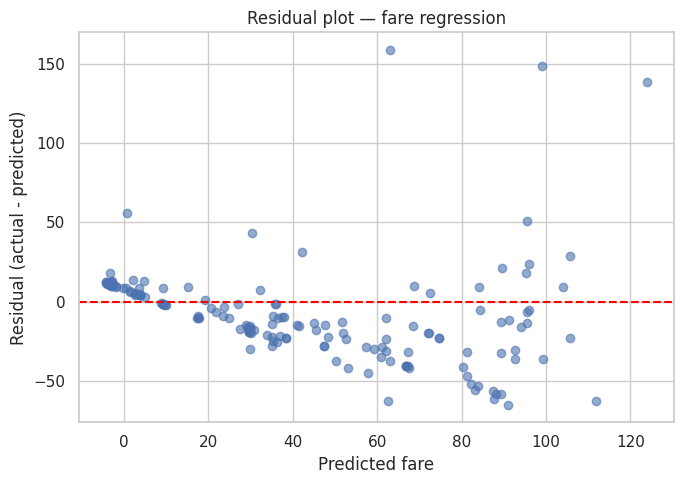

In [12]:
residuals = yr_test - fare_pred

plt.figure(figsize=(7, 5))
plt.scatter(fare_pred, residuals, alpha=0.6, color='#4C72B0')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted fare')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot — fare regression')
plt.tight_layout()
plt.savefig('charts/11_residual_plot.png', dpi=150)
plt.show()


## Task 13 — Final model comparison table and recommendation

In [13]:
print("=== Classification metrics (3 classifiers) ===")
display(classifier_comparison)

print("\n=== Regression metrics (fare prediction) ===")
regression_metrics = pd.DataFrame({
    'MAE': [mae], 'RMSE': [rmse], 'R2': [r2], 'Adjusted R2': [adj_r2]
}, index=['Linear Regression (fare)']).round(4)
display(regression_metrics)


=== Classification metrics (3 classifiers) ===


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8435
Decision Tree,0.7765,0.8085,0.5507,0.6552,0.8144
Random Forest,0.8101,0.7778,0.7101,0.7424,0.8310



=== Regression metrics (fare prediction) ===


,MAE,RMSE,R2,Adjusted R2
Linear Regression (fare),20.8977,30.5328,0.3975,0.3729


In [14]:
best_model_name = classifier_comparison['F1'].idxmax()
print("Best classifier by F1:", best_model_name)
print(classifier_comparison.loc[best_model_name])


Best classifier by F1: Random Forest
Accuracy     0.8101
Precision    0.7778
Recall       0.7101
F1           0.7424
AUC          0.8310
Name: Random Forest, dtype: float64


## Task 14 — Save the best full pipeline with `joblib`

In [15]:
full_pipeline = best_rf_pipe  # ColumnTransformer + tuned RandomForestClassifier, already fit
joblib.dump(full_pipeline, 'titanic_full_pipeline.joblib')
print("Saved: titanic_full_pipeline.joblib")


Saved: titanic_full_pipeline.joblib


In [16]:
# Reload and confirm it still predicts correctly on raw (unpreprocessed) input
reloaded_pipeline = joblib.load('titanic_full_pipeline.joblib')

raw_sample = X_test.iloc[:5]
original_preds = full_pipeline.predict(raw_sample)
reloaded_preds = reloaded_pipeline.predict(raw_sample)

print("Raw sample input:")
display(raw_sample)
print("Original pipeline predictions: ", original_preds)
print("Reloaded pipeline predictions: ", reloaded_preds)
print("Match:", (original_preds == reloaded_preds).all())


Raw sample input:


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q


Original pipeline predictions:  [0 0 0 0 1]
Reloaded pipeline predictions:  [0 0 0 0 1]
Match: True


## Summary

- Stratified 80/20 split on `survived`, preprocessing fit only on the training fold via a shared
  `ColumnTransformer`.
- Three classifiers trained and evaluated with a full metric suite + ROC/AUC; Decision Tree
  visualized with `plot_tree`.
- Imbalance-handling comparison (baseline / `class_weight='balanced'` / SMOTE-on-train-fold-only)
  with a written conclusion.
- `GridSearchCV`-tuned Random Forest with OOB score reported.
- Regression side-task predicting `fare`, with MAE/RMSE/R²/Adjusted R² and a heteroscedasticity
  conclusion from the residual plot.
- Final comparison table (classification metrics and regression metrics kept as separate groups)
  and a written recommendation.
- The complete best-performing pipeline saved via `joblib.dump` and confirmed reloadable and
  usable end-to-end on raw input.
